In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Better chart appearance
plt.style.use('ggplot')

# Display all columns
pd.set_option('display.max_columns', None)

In [22]:
df = pd.read_csv(
    '../datasets/cleaned/cleaned_sales_data.csv'
)

In [23]:
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,profit_margin_percent,order_year,order_month,order_month_name,shipping_days
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,OFF-TEN-10000025,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011,26.014706,2011,1,January,5
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,OFF-SU-10000618,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011,30.030000,2011,1,January,7
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,OFF-TEN-10001585,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011,44.909091,2011,1,January,4
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,OFF-PA-10001492,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011,-57.900000,2011,1,January,4
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,FUR-FU-10003447,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011,33.131579,2011,1,January,7


In [24]:
df['order_date'] = pd.to_datetime(df['order_date'])

In [25]:
df['order_month_name'] = (
    df['order_date']
    .dt.month_name()
)

In [26]:
#---month order for plotting
month_order = [
    'January', 'February', 'March',
    'April', 'May', 'June',
    'July', 'August', 'September',
    'October', 'November', 'December'
]

In [27]:
#--KPI calculations
total_sales = df['sales'].sum()

total_profit = df['profit'].sum()

profit_margin = (
    total_profit / total_sales
) * 100

total_orders = df['order_id'].nunique()

total_customers = df['customer_name'].nunique()

In [28]:
#--Sales by month
monthly_sales = (
    df.groupby('order_month_name')['sales']
    .sum()
    .reset_index()
)

monthly_sales['order_month_name'] = pd.Categorical(
    monthly_sales['order_month_name'],
    categories=month_order,
    ordered=True
)

monthly_sales = monthly_sales.sort_values(
    'order_month_name'
)

In [29]:
category_sales = (
    df.groupby('category')['sales']
    .sum()
    .sort_values(ascending=False)
)

In [30]:
segment_sales = (
    df.groupby('segment')['sales']
    .sum()
)

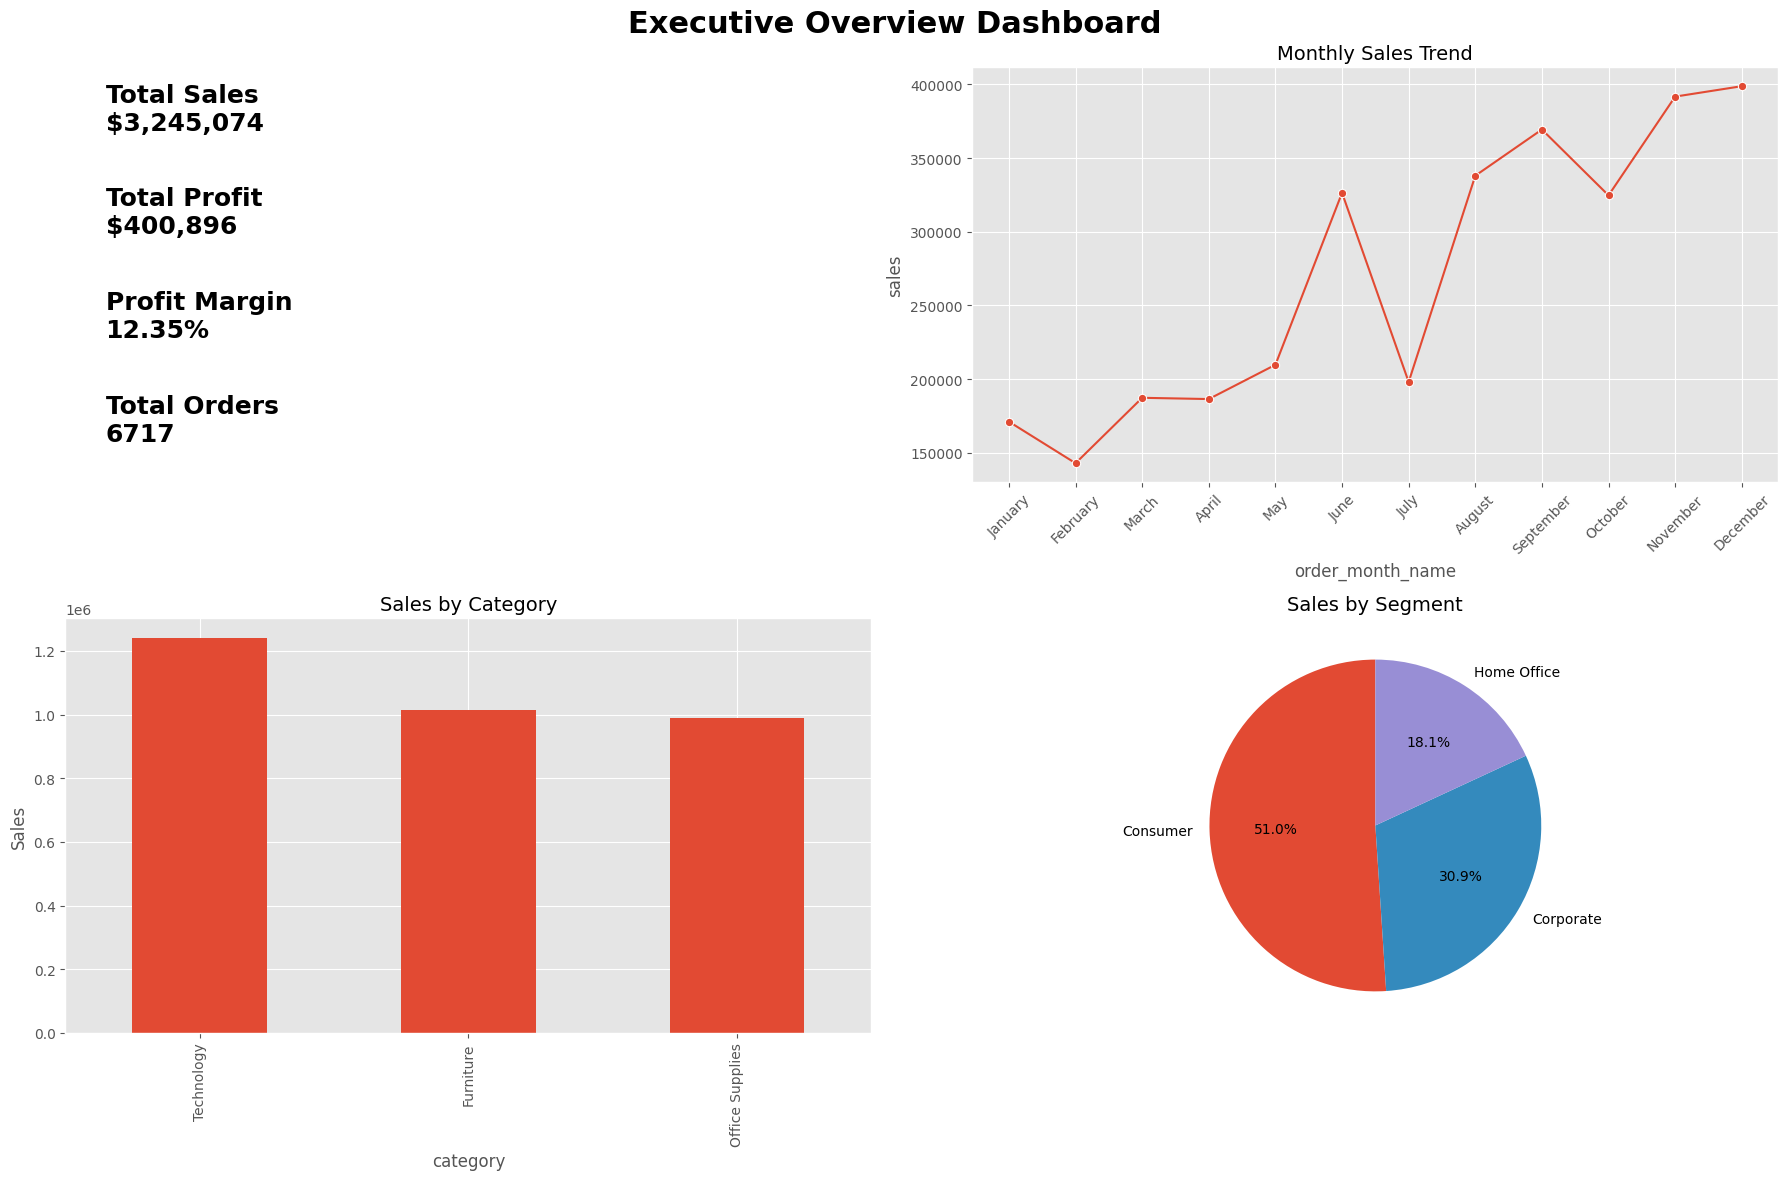

In [31]:
#--dashboard layout
fig, ax = plt.subplots(
    2, 2,
    figsize=(18,12)
)

fig.suptitle(
    'Executive Overview Dashboard',
    fontsize=22,
    fontweight='bold'
)

# =========================
# KPI TEXT
# =========================

ax[0,0].text(
    0.05, 0.85,
    f'Total Sales\n${total_sales:,.0f}',
    fontsize=18,
    fontweight='bold'
)

ax[0,0].text(
    0.05, 0.60,
    f'Total Profit\n${total_profit:,.0f}',
    fontsize=18,
    fontweight='bold'
)

ax[0,0].text(
    0.05, 0.35,
    f'Profit Margin\n{profit_margin:.2f}%',
    fontsize=18,
    fontweight='bold'
)

ax[0,0].text(
    0.05, 0.10,
    f'Total Orders\n{total_orders}',
    fontsize=18,
    fontweight='bold'
)

ax[0,0].axis('off')

# =========================
# MONTHLY SALES TREND
# =========================

sns.lineplot(
    data=monthly_sales,
    x='order_month_name',
    y='sales',
    marker='o',
    ax=ax[0,1]
)

ax[0,1].set_title(
    'Monthly Sales Trend',
    fontsize=14
)

ax[0,1].tick_params(axis='x', rotation=45)

# =========================
# CATEGORY SALES
# =========================

category_sales.plot(
    kind='bar',
    ax=ax[1,0]
)

ax[1,0].set_title(
    'Sales by Category',
    fontsize=14
)

ax[1,0].set_ylabel('Sales')

# =========================
# SEGMENT SALES PIE
# =========================

ax[1,1].pie(
    segment_sales,
    labels=segment_sales.index,
    autopct='%1.1f%%',
    startangle=90
)

ax[1,1].set_title(
    'Sales by Segment',
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    '../powerbi/dashboard_screenshots/overview.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## regional Sales

In [33]:
regional_sales = (
    df.groupby('region')['sales']
    .sum()
    .sort_values(ascending=False)
)

In [34]:
regional_profit = (
    df.groupby('region')['profit']
    .sum()
    .sort_values(ascending=False)
)

In [36]:
#--top states by sales
top_states = (
    df.groupby('state')['sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

In [37]:
#--regional profit margin
regional_margin = (
    df.groupby('region')['profit']
    .sum()
    /
    df.groupby('region')['sales']
    .sum()
) * 100

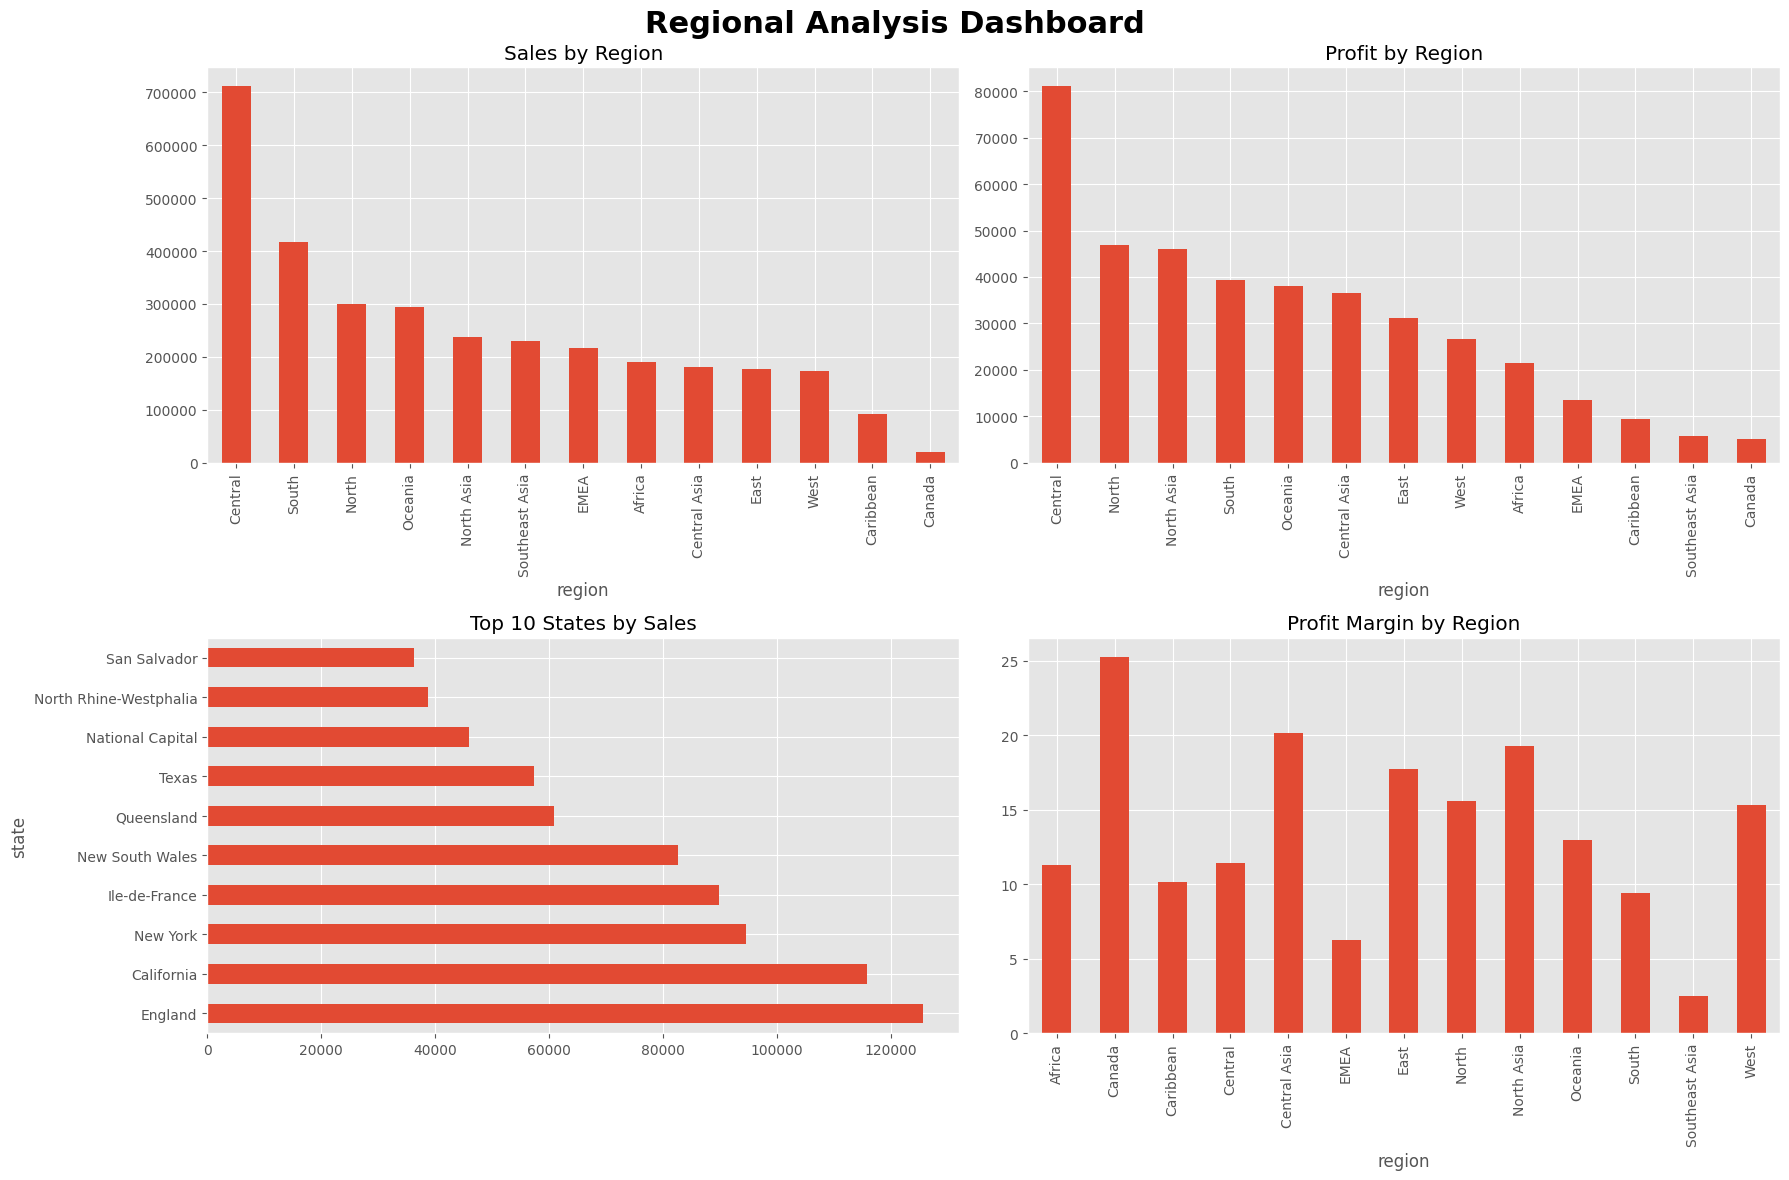

In [38]:
#--regional analysis dashboard layout
fig, ax = plt.subplots(
    2, 2,
    figsize=(18,12)
)

fig.suptitle(
    'Regional Analysis Dashboard',
    fontsize=22,
    fontweight='bold'
)

# =========================
# SALES BY REGION
# =========================

regional_sales.plot(
    kind='bar',
    ax=ax[0,0]
)

ax[0,0].set_title(
    'Sales by Region'
)

# =========================
# PROFIT BY REGION
# =========================

regional_profit.plot(
    kind='bar',
    ax=ax[0,1]
)

ax[0,1].set_title(
    'Profit by Region'
)

# =========================
# TOP STATES
# =========================

top_states.plot(
    kind='barh',
    ax=ax[1,0]
)

ax[1,0].set_title(
    'Top 10 States by Sales'
)

# =========================
# PROFIT MARGIN
# =========================

regional_margin.plot(
    kind='bar',
    ax=ax[1,1]
)

ax[1,1].set_title(
    'Profit Margin by Region'
)

plt.tight_layout()

plt.savefig(
    '../powerbi/dashboard_screenshots/regional_analysis.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Profitability insights

In [39]:
losses = (
    df.groupby('sub_category')['profit']
    .sum()
    .sort_values()
    .head(10)
)

In [40]:
category_profit = (
    df.groupby('category')['profit']
    .sum()
)

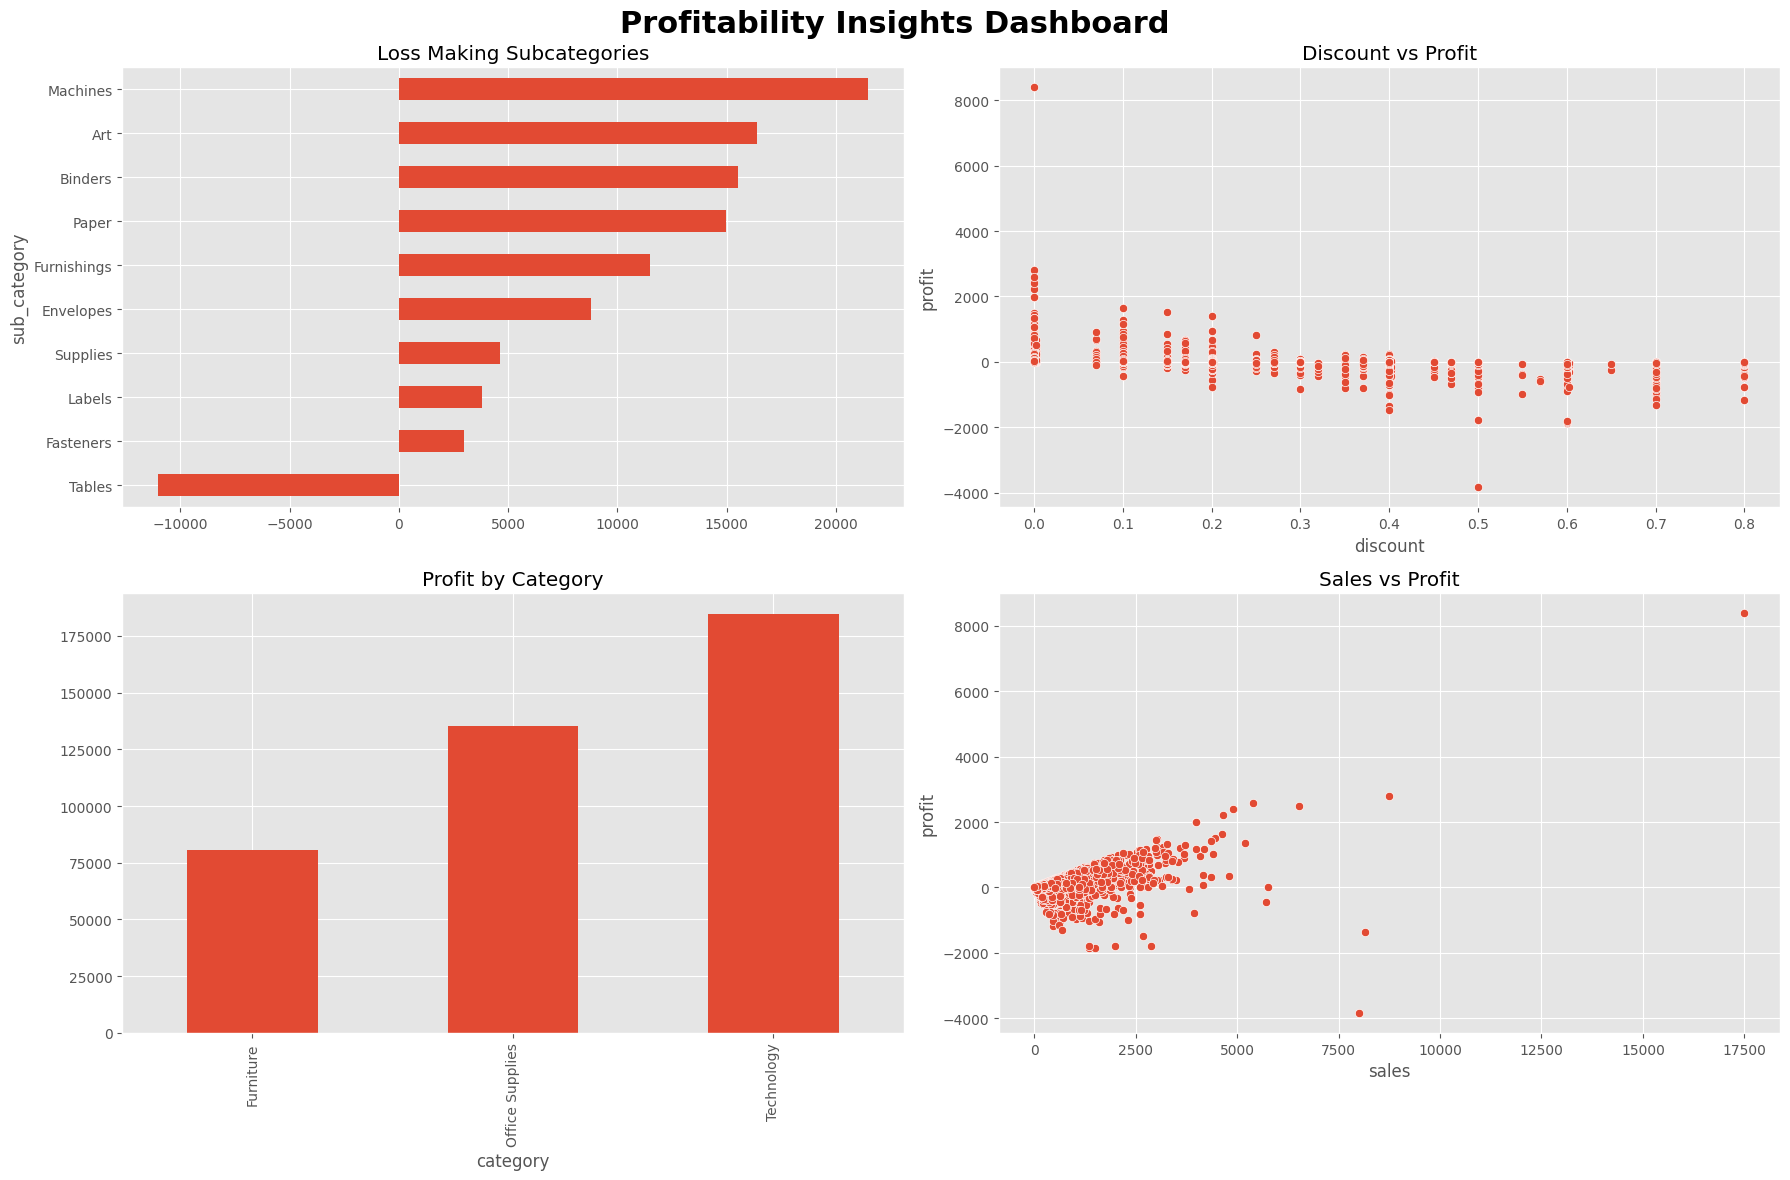

In [41]:
#--dashboard layout
fig, ax = plt.subplots(
    2, 2,
    figsize=(18,12)
)

fig.suptitle(
    'Profitability Insights Dashboard',
    fontsize=22,
    fontweight='bold'
)

# =========================
# LOSS MAKING SUBCATEGORIES
# =========================

losses.plot(
    kind='barh',
    ax=ax[0,0]
)

ax[0,0].set_title(
    'Loss Making Subcategories'
)

# =========================
# DISCOUNT VS PROFIT
# =========================

sns.scatterplot(
    data=df,
    x='discount',
    y='profit',
    ax=ax[0,1]
)

ax[0,1].set_title(
    'Discount vs Profit'
)

# =========================
# CATEGORY PROFIT
# =========================

category_profit.plot(
    kind='bar',
    ax=ax[1,0]
)

ax[1,0].set_title(
    'Profit by Category'
)

# =========================
# SALES VS PROFIT
# =========================

sns.scatterplot(
    data=df,
    x='sales',
    y='profit',
    ax=ax[1,1]
)

ax[1,1].set_title(
    'Sales vs Profit'
)

plt.tight_layout()

plt.savefig(
    '../powerbi/dashboard_screenshots/profitability.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()